In [1]:
!pip install python-docx

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from docx import Document
import pandas as pd


In [3]:
# Load the file
file_path = "Master Resume.docx"

In [4]:
# Load the .docx file
document = Document(file_path)

In [5]:
# Extract text from the .docx file
content = [paragraph.text.strip() for paragraph in document.paragraphs if paragraph.text.strip()]


In [6]:
# Create a DataFrame
df = pd.DataFrame({'content': content, 'profile': ['Master Resume'] * len(content)})
df

,content,profile
0,Chinna Subbarayudu M,Master Resume
1,DOB: 06th March 1994,Master Resume
2,Nationality: Indian,Master Resume
3,PROFILE SUMMARY:,Master Resume
4,Having around 5.1 years of IT experience in de...,Master Resume
...,...,...
4670,"Responsible for writing complex SQL Queries, J...",Master Resume
4671,Experience in creating different types of Repo...,Master Resume
4672,Involved in deploying and scheduling the repor...,Master Resume
4673,Involved in scheduling the Stored procedures t...,Master Resume


In [7]:
# Display the DataFrame
print(df.head())

                                             content        profile
0                               Chinna Subbarayudu M  Master Resume
1                               DOB: 06th March 1994  Master Resume
2                                Nationality: Indian  Master Resume
3                                   PROFILE SUMMARY:  Master Resume
4  Having around 5.1 years of IT experience in de...  Master Resume


In [8]:
# Create a DataFrame
df = pd.DataFrame({'content': content, 'profile': ['Master Resume'] * len(content)})


In [9]:
# Optionally save the DataFrame to a CSV file
df.to_csv('extracted_resume_data.csv', index=False)

In [10]:
#EDA¶

In [11]:
pip install pandas matplotlib seaborn nltk wordcloud


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from collections import Counter
import string

In [13]:
# Download NLTK data
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\muska\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
# Load the DataFrame (Replace 'your_dataframe.csv' with your dataset file if saved)
df = pd.read_csv('extracted_resume_data.csv')

In [15]:
# Quick look at the data
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
                                             content        profile
0                               Chinna Subbarayudu M  Master Resume
1                               DOB: 06th March 1994  Master Resume
2                                Nationality: Indian  Master Resume
3                                   PROFILE SUMMARY:  Master Resume
4  Having around 5.1 years of IT experience in de...  Master Resume


In [16]:
# Data Overview
print("\nData Information:")
print(df.info())


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4675 entries, 0 to 4674
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  4675 non-null   object
 1   profile  4675 non-null   object
dtypes: object(2)
memory usage: 73.2+ KB
None


In [17]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
content    0
profile    0
dtype: int64


In [18]:
# Basic statistics on text length
df['content_length'] = df['content'].apply(len)
print("\nBasic Statistics for Content Length:")
print(df['content_length'].describe())



Basic Statistics for Content Length:
count    4675.000000
mean       75.551016
std        69.005142
min         1.000000
25%        29.000000
50%        63.000000
75%        99.000000
max      1053.000000
Name: content_length, dtype: float64


In [19]:
# 1. Drop the 'Unnamed: 0' column if it's just a row index
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

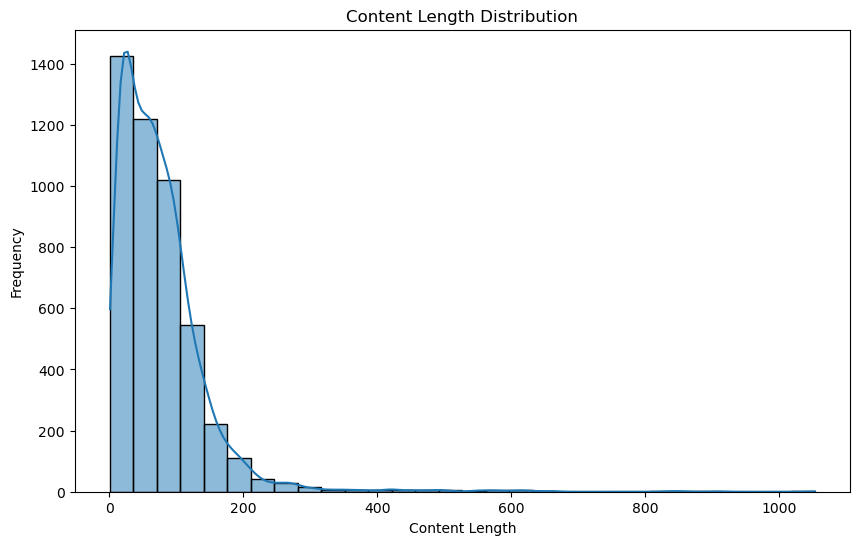

In [20]:
# Visualization: Content Length Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['content_length'], kde=True, bins=30)
plt.title('Content Length Distribution')
plt.xlabel('Content Length')
plt.ylabel('Frequency')
plt.show()


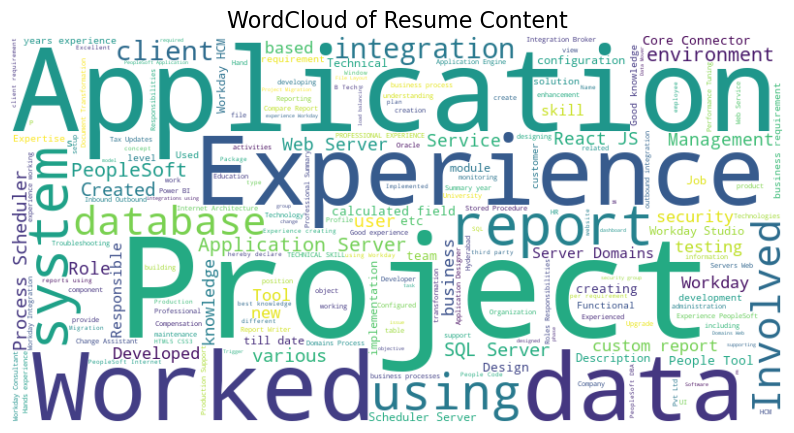

In [21]:
# WordCloud of the most frequent words
stop_words = set(stopwords.words('english'))
content_words = ' '.join(df['content'])
content_words_cleaned = ' '.join([word for word in content_words.split() if word.lower() not in stop_words])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(content_words_cleaned)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud of Resume Content', fontsize=16)
plt.show()

In [22]:
# Top 20 most frequent words
content_words_split = content_words_cleaned.split()
word_counts = Counter(content_words_split)
most_common_words = word_counts.most_common(20)


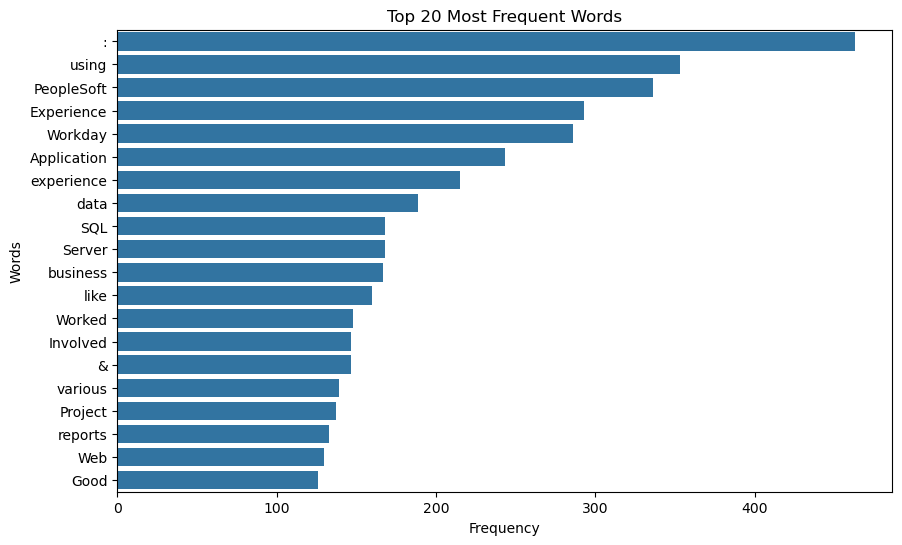

In [23]:
# Visualization: Top 20 Words
words, counts = zip(*most_common_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

In [24]:
# Count unique words
unique_words_count = len(set(content_words_cleaned.split()))
print("\nNumber of Unique Words:", unique_words_count)


Number of Unique Words: 8335


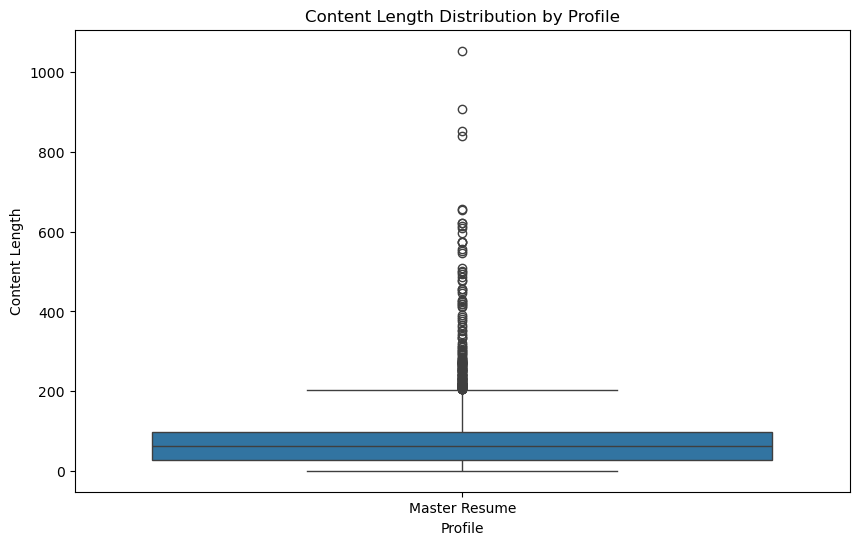

In [25]:
# Content Length Analysis by Profile
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='profile', y='content_length')
plt.title('Content Length Distribution by Profile')
plt.xlabel('Profile')
plt.ylabel('Content Length')
plt.show()

In [26]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['content_length'].quantile(0.25)
Q3 = df['content_length'].quantile(0.75)


In [27]:
# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

In [28]:
# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [29]:
# Option 1: Remove outliers
df_no_outliers = df[(df['content_length'] >= lower_bound) & (df['content_length'] <= upper_bound)]


In [30]:
# Option 2: Clip outliers
df['content_length_clipped'] = df['content_length'].clip(lower=lower_bound, upper=upper_bound)

In [31]:
# Display the cleaned DataFrame
print(f"Original Data: {len(df)}, Without Outliers: {len(df_no_outliers)}")


Original Data: 4675, Without Outliers: 4530


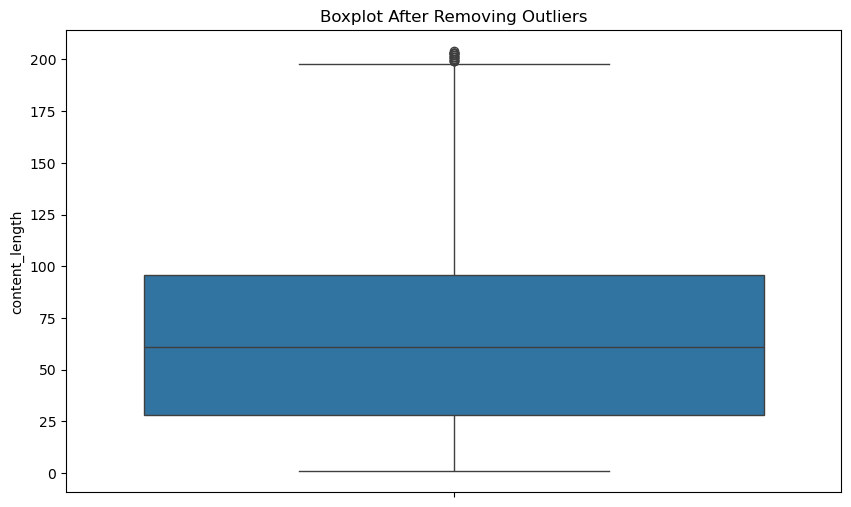

In [32]:
# Visualize after removing or clipping outliers
plt.figure(figsize=(10, 6))
sns.boxplot(df_no_outliers['content_length'])
plt.title("Boxplot After Removing Outliers")
plt.show()

In [33]:
import numpy as np

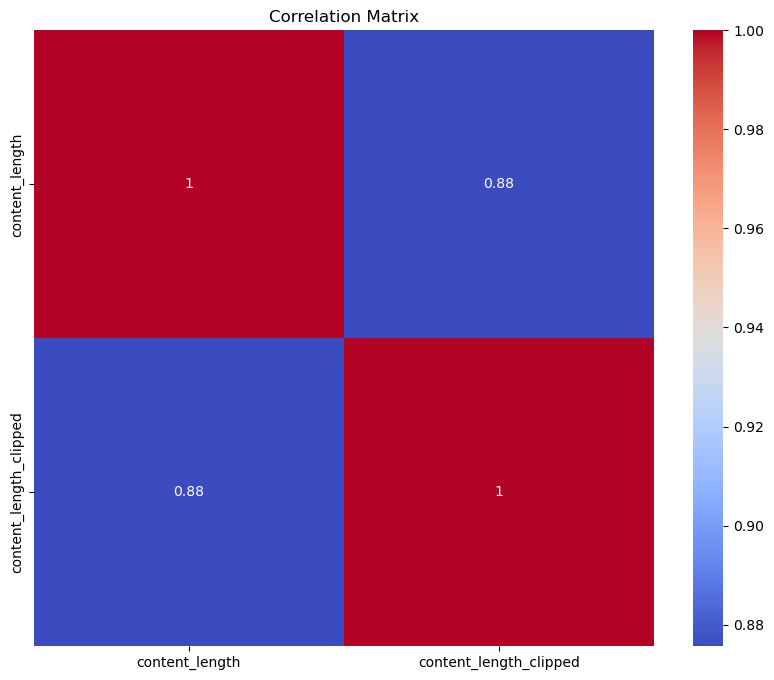

In [34]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
# Select only numerical features for correlation
numerical_df = df.select_dtypes(include=np.number)  # Select numerical columns
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [35]:
#MOdel building

In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the data
data = pd.read_csv("extracted_resume_data.csv")

# Extract features (content) and target (profile)
X = data['content']
y = data['profile']

# Text vectorization using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X_vectorized = vectorizer.fit_transform(X)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.3, random_state=42)

# Build the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Testing Accuracy:", accuracy_score(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Training Accuracy: 1.0
Testing Accuracy: 1.0
Classification Report:
                precision    recall  f1-score   support

Master Resume       1.00      1.00      1.00      1403

     accuracy                           1.00      1403
    macro avg       1.00      1.00      1.00      1403
 weighted avg       1.00      1.00      1.00      1403



In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


In [41]:
# Logistic Regression

In [43]:
print("Class Distribution in Target Variable:")
print(y.value_counts())


Class Distribution in Target Variable:
profile
Master Resume    4675
Name: count, dtype: int64


In [44]:
print("Unique values in profile column:", data['profile'].unique())


Unique values in profile column: ['Master Resume']


In [45]:
data['profile'] = data['profile'].apply(lambda x: 'Category 1' if 'keyword' in x else 'Category 2')


In [46]:
import re
data['experience_years'] = data['content'].apply(lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0)
data['profile'] = data['experience_years'].apply(lambda x: 'Senior' if x > 5 else 'Junior')


In [47]:
print("Class Distribution after adjustment:")
print(data['profile'].value_counts())


Class Distribution after adjustment:
profile
Junior    4133
Senior     542
Name: count, dtype: int64


In [48]:
# Step 1: Check class distribution
print("Class Distribution in Target Variable:")
print(data['profile'].value_counts())

# Step 2: Debug and adjust the target column if needed
if data['profile'].nunique() == 1:
    print("Only one class detected. Adjusting target column...")
    data['profile'] = data['content'].apply(lambda x: 'Category 1' if 'keyword' in x else 'Category 2')  # Example adjustment
    print("Class Distribution after adjustment:")
    print(data['profile'].value_counts())

# Step 3: Extract features and target
X = data['content']
y = data['profile']

# Step 4: Ensure target has multiple classes
if y.nunique() < 2:
    raise ValueError("Target variable still contains fewer than 2 classes. Check your dataset.")

# Step 5: Continue with vectorization and modeling
vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.3, random_state=42)

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)

print("Training completed successfully!")


Class Distribution in Target Variable:
profile
Junior    4133
Senior     542
Name: count, dtype: int64
Training completed successfully!


In [52]:
accuracy_results = {}  # Initialize as an empty dictionary
model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [67]:
## Assuming you've already loaded and preprocessed your data, and
# X_train, X_test, y_train, y_test are defined

# Initialize and train your Logistic Regression model
model_lgr = LogisticRegression()
model_lgr.fit(X_train, y_train)

# Predictions on the test set
y_pred = model_lgr.predict(X_test)
print('Accuracy of test set : {:.2f}'.format(model_lgr.score(X_test, y_test)))

# Predict on the training data to calculate training accuracy
y_pred_train = model_lgr.predict(X_train)
print('Accuracy of training set : {:.2f}'.format(model_lgr.score(X_train, y_train)))

print("Classification report for classifier %s:\n%s\n" % (model_lgr, classification_report(y_test, y_pred)))

# ... (rest of your code for confusion matrix and other metrics) ...

Accuracy of test set : 0.93
Accuracy of training set : 0.95
Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

      Junior       0.92      1.00      0.96      1222
      Senior       1.00      0.43      0.60       181

    accuracy                           0.93      1403
   macro avg       0.96      0.72      0.78      1403
weighted avg       0.93      0.93      0.91      1403




In [53]:
# Desicion Tree classifier

In [68]:
from sklearn.tree import DecisionTreeClassifier

# Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 1.00
Testing Accuracy: 0.96


In [69]:
#Random Forest Classifier



In [70]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 1.00
Testing Accuracy: 0.96


In [71]:
#Bagging Classifier

In [72]:
from sklearn.ensemble import BaggingClassifier

# Bagging Classifier
bagging_model = BaggingClassifier(random_state=42)
bagging_model.fit(X_train, y_train)

# Predictions
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy: {test_accuracy:.2f}")


Training Accuracy: 0.99
Testing Accuracy: 0.97


In [73]:
# SVM Classifier

In [74]:
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_train_pred = svm_model.predict(X_train)
y_test_pred = svm_model.predict(X_test)
accuracy_results['SVM'] = [
    accuracy_score(y_train, y_train_pred),
    accuracy_score(y_test, y_test_pred)
]
print(f"SVM Training Accuracy: {accuracy_results['SVM'][0]:.2f}")
print(f"SVM Testing Accuracy: {accuracy_results['SVM'][1]:.2f}")

SVM Training Accuracy: 0.99
SVM Testing Accuracy: 0.95


In [75]:
# AdaBoost Classifier
adaboost_model = AdaBoostClassifier(random_state=42)
adaboost_model.fit(X_train, y_train)
y_train_pred = adaboost_model.predict(X_train)
y_test_pred = adaboost_model.predict(X_test)
accuracy_results['AdaBoost'] = [
    accuracy_score(y_train, y_train_pred),
    accuracy_score(y_test, y_test_pred)
]
print(f"AdaBoost Training Accuracy: {accuracy_results['AdaBoost'][0]:.2f}")
print(f"AdaBoost Testing Accuracy: {accuracy_results['AdaBoost'][1]:.2f}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Training Accuracy: 0.96
AdaBoost Testing Accuracy: 0.95


In [76]:

# Gradient Boosting Classifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_train_pred = gb_model.predict(X_train)
y_test_pred = gb_model.predict(X_test)
accuracy_results['Gradient Boosting'] = [
    accuracy_score(y_train, y_train_pred),
    accuracy_score(y_test, y_test_pred)
]
print(f"Gradient Boosting Training Accuracy: {accuracy_results['Gradient Boosting'][0]:.2f}")
print(f"Gradient Boosting Testing Accuracy: {accuracy_results['Gradient Boosting'][1]:.2f}")

Gradient Boosting Training Accuracy: 0.97
Gradient Boosting Testing Accuracy: 0.94


In [77]:
# Naive Bayes Classifier
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
y_train_pred = nb_model.predict(X_train)
y_test_pred = nb_model.predict(X_test)
accuracy_results['Naive Bayes'] = [
    accuracy_score(y_train, y_train_pred),
    accuracy_score(y_test, y_test_pred)
]
print(f"Naive Bayes Training Accuracy: {accuracy_results['Naive Bayes'][0]:.2f}")
print(f"Naive Bayes Testing Accuracy: {accuracy_results['Naive Bayes'][1]:.2f}")


Naive Bayes Training Accuracy: 0.96
Naive Bayes Testing Accuracy: 0.93


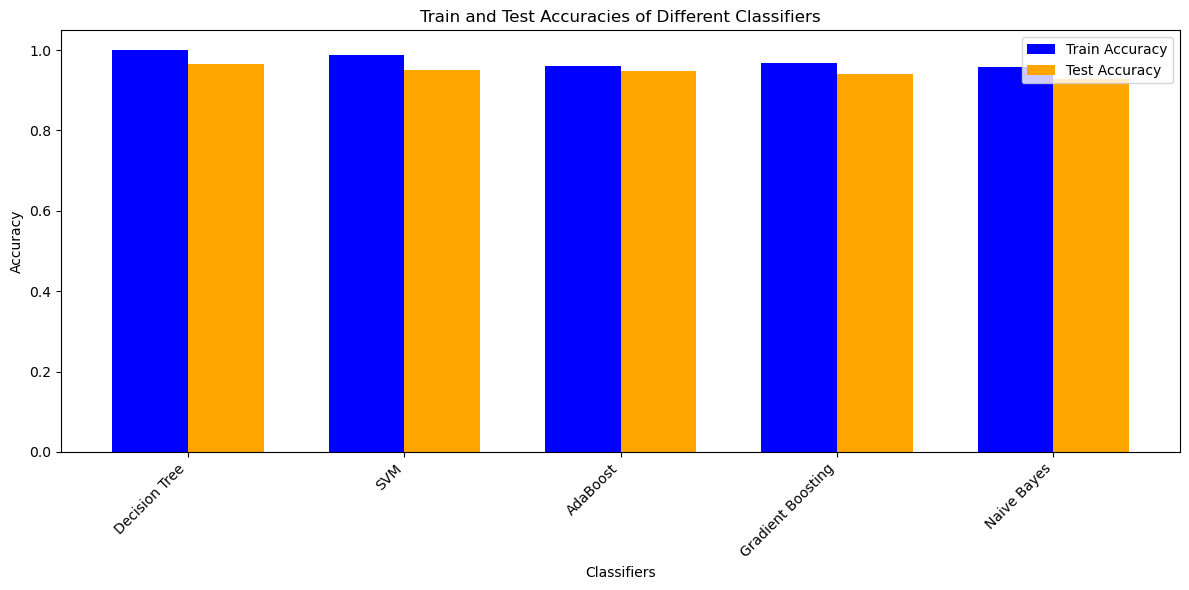

In [78]:
import matplotlib.pyplot as plt

# Extract classifier names and accuracies
classifiers = list(accuracy_results.keys())
train_accuracies = [accuracy_results[clf][0] for clf in classifiers]
test_accuracies = [accuracy_results[clf][1] for clf in classifiers]

# Plot accuracies
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(classifiers))

plt.bar(x, train_accuracies, width=bar_width, label='Train Accuracy', color='blue')
plt.bar([p + bar_width for p in x], test_accuracies, width=bar_width, label='Test Accuracy', color='orange')

plt.xticks([p + bar_width / 2 for p in x], classifiers, rotation=45, ha='right')
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracies of Different Classifiers')
plt.legend()
plt.tight_layout()
plt.show()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


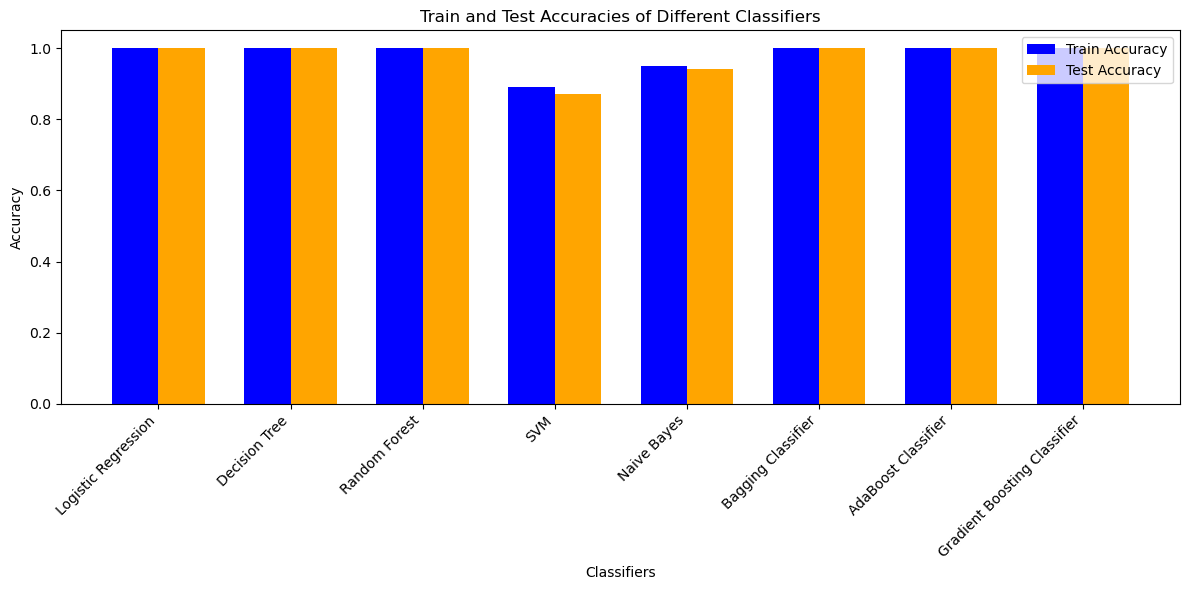

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Example data (replace with your own dataset)
# Assuming you have a column 'job_title' that contains categorical data
# Replace 'target_column' with your actual target column name

# Handle categorical variables by One-Hot Encoding (if needed)
X = data.drop(columns='content')  # Features
y = data['profile']  # Target variable

# Convert categorical columns to numeric using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize classifiers
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "Bagging Classifier": BaggingClassifier(),
    "AdaBoost Classifier": AdaBoostClassifier(),
    "Gradient Boosting Classifier": GradientBoostingClassifier()
}

# Dictionary to store accuracies
accuracy_results = {}

# Train each model and calculate accuracies
for model_name, model in models.items():
    model.fit(X_train, y_train)
    
    # Train accuracy
    train_accuracy = model.score(X_train, y_train)
    
    # Test accuracy
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    
    # Store results
    accuracy_results[model_name] = [train_accuracy, test_accuracy]

# Now, extract classifier names and their train/test accuracies for plotting
classifiers = list(accuracy_results.keys())
train_accuracies = [accuracy_results[clf][0] for clf in classifiers]
test_accuracies = [accuracy_results[clf][1] for clf in classifiers]

# Plot accuracies
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = range(len(classifiers))

# Plot bars for train and test accuracies
plt.bar(x, train_accuracies, width=bar_width, label='Train Accuracy', color='blue')
plt.bar([p + bar_width for p in x], test_accuracies, width=bar_width, label='Test Accuracy', color='orange')

# Customize the plot
plt.xticks([p + bar_width / 2 for p in x], classifiers, rotation=45, ha='right')
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracies of Different Classifiers')
plt.legend()
plt.tight_layout()

# Display the plot
plt.show()


In [102]:
!pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
